In [1]:
import itertools
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [2]:
GRID_START = "2012-01-01"

# --- Equity candidates that replace SPY ---
EQUITY_CANDS = [
    "QLD",
    "QQQ",

]   # <- put as many as you want here

# Other risky sleeves (kept as-is)
OTHER_SLEEVES = ["SMH","HYMB", "IAU"]


# Defensive sleeve
CASH = "BIL"

REB = "W"                         # monthly rebalance
COST_BPS = 5                      # one-way trading cost (simple)

# Fixed MA windows
DEFAULT_MA = 150
MA_FIXED = {
    "SMH":200,
    "ITOT": 210,
    "IEF": 50,
    "IVW": 200,
    "QQQ": 150,
    "QLQ": 150,
    "EFA": 120,
    "HYMB": 50,
    "IAU": 125,
}


# Dual Momentum settings (relative momentum lookback)
EMA_ALPHA=0.30
MOM_LKBK = 84       # ~12 months of trading days
VOL_LKBK=60
MOM_SKIP = 21        # skip last ~1 month; set 0 to disable
REQ_POS_MOM = True   # Require best equity momentum to be > 0

In [3]:
static_cfg = dict(
    EQUITY_CANDS=EQUITY_CANDS,
    OTHER_SLEEVES=OTHER_SLEEVES,
    CASH=CASH,
    MA_FIXED=MA_FIXED,
    DEFAULT_MA=DEFAULT_MA,
    MOM_SKIP=MOM_SKIP,
    REQ_POS_MOM=REQ_POS_MOM,
    COST_BPS=COST_BPS,
    #MOM_LKBK=MOM_LKBK,
    VOL_LKBK=VOL_LKBK,
    EMA_ALPHA=EMA_ALPHA
)

param_grid = {
    "MOM_LKBK": [63, 84, 126, 168, 252],
    # "VOL_LKBK":  [40, 60, 90],
    # "EMA_ALPHA": [None, 0.15, 0.30, 0.50],
    "VT_TARGET": [None, 0.08, 0.10, 0.12],
    "VT_LKBK":   [40, 60, 90],
    "GROSS_CAP": [1.00, 1.25, 1.50],
}


In [4]:
# =========================
# Helpers
# =========================
def kpi(ser: pd.Series):
    s = ser.dropna()
    if s.empty:
        return dict(CAGR=np.nan, Sharpe=np.nan, Vol=np.nan, Sortino=np.nan, MaxDD=np.nan)
    cum = (1 + s).cumprod()
    yrs = (s.index[-1] - s.index[0]).days / 365.25
    cagr = cum.iloc[-1] ** (1 / yrs) - 1 if yrs > 0 else np.nan
    vol = s.std() * np.sqrt(252)
    sharpe = (s.mean() * 252) / vol if vol > 0 else np.nan
    mdd = (cum / cum.cummax() - 1).min()
    dvol = s[s < 0].std() * np.sqrt(252) if (s < 0).sum() > 1 else np.nan
    sortino = (s.mean() * 252) / dvol if (isinstance(dvol, float) and dvol > 0) else np.nan
    return dict(CAGR=cagr, Sharpe=sharpe, Vol=vol, Sortino=sortino, MaxDD=mdd)


def ma_signal(series: pd.Series, win: int) -> pd.Series:
    ma = series.rolling(win).mean()
    return (series > ma).astype(int)

def momentum_score(series: pd.Series, asof: pd.Timestamp, lookback: int, skip: int) -> float:
    """
    Dual momentum-style score:
      - Use price(asof - skip) / price(asof - lookback - skip) - 1
      - skip=21 approximates excluding most recent month
    """
    s = series.loc[:asof].dropna()
    if len(s) < (lookback + skip + 5):
        return np.nan
    end = s.iloc[-1 - skip] if skip > 0 else s.iloc[-1]
    start = s.iloc[-1 - skip - lookback]
    if start <= 0 or end <= 0:
        return np.nan
    return float(end / start - 1.0)


In [20]:


def portfolio_returns_param(
    W: pd.DataFrame,
    rets: pd.DataFrame,
    COST_BPS: float,
    vt_target: float | None,
    VT_LKBK: int,
    GROSS_CAP: float,
):
    """
    Same logic as your portfolio_returns(), but parameterized.
    """
    dW = W.reindex(rets.index).ffill().fillna(0.0)
    gross = (dW.shift(1) * rets).sum(axis=1)

    # trading costs on rebalance days
    Wprev = W.shift(1).fillna(0.0)
    tnov = (W - Wprev).abs().sum(axis=1)
    tcost = tnov * (COST_BPS / 10000.0)

    cost = pd.Series(0.0, index=gross.index)
    reb_days = cost.index.intersection(W.index)
    cost.loc[reb_days] = tcost.reindex(reb_days).fillna(0.0)

    pr = gross - cost

    # vol targeting (shift scale by 1 day to avoid same-day lookahead)
    if vt_target is not None:
        roll = pr.rolling(VT_LKBK).std() * np.sqrt(252)
        scale = (vt_target / roll.replace(0, np.nan)).clip(upper=GROSS_CAP)
        scale = scale.shift(1).fillna(1.0)
        pr = pr * scale

    return pr

def invvol_weights_param(
    names: list[str],
    asof: pd.Timestamp,
    px_cols: pd.Index,
    rets: pd.DataFrame,
    lookback: int,
    gamma: float = 0.6,
    vol_floor: float = 0.06,
    w_cap: float = 0.60,
):
    """
    Same logic as your invvol_weights(), but parameterized.
    """
    w = pd.Series(0.0, index=px_cols)
    if not names:
        return w

    sub = rets[names].loc[:asof].tail(lookback)
    if sub.empty:
        return w

    vol = sub.std().clip(lower=vol_floor)
    inv = 1 / (vol ** gamma)
    inv = inv / inv.sum()

    inv = inv.clip(upper=w_cap)
    inv = inv / inv.sum()

    w.loc[names] = inv
    return w

def build_weights_no_macro_param(
    px: pd.DataFrame,
    rets: pd.DataFrame,
    rbd: pd.DatetimeIndex,
    EQUITY_CANDS: list[str],
    OTHER_SLEEVES: list[str],
    CASH: str,
    MA_FIXED: dict,
    DEFAULT_MA: int,
    MOM_LKBK: int,
    MOM_SKIP: int,
    REQ_POS_MOM: bool,
    VOL_LKBK: int,
    EMA_ALPHA: float | None,
):
    # Precompute MA signals; shift by 1 day to remove lookahead
    gate_tickers = list(dict.fromkeys(EQUITY_CANDS + OTHER_SLEEVES))
    sig = {}
    for t in gate_tickers:
        if t in px.columns:
            win = MA_FIXED.get(t, DEFAULT_MA)
            sig[t] = ma_signal(px[t], win).shift(1).reindex(px.index).fillna(0)

    W = pd.DataFrame(index=rbd, columns=px.columns, data=0.0)
    ema_prev = None

    for d in rbd:
        loc = px.index.get_loc(d)
        if isinstance(loc, slice) or isinstance(loc, np.ndarray):
            loc = loc.stop - 1
        if loc == 0:
            continue
        asof = px.index[loc - 1]

        # 1) Dual Momentum equity pick among MA-on equities
        eq_on = [
            t for t in EQUITY_CANDS
            if (t in sig) and int(sig[t].loc[asof]) == 1 and (t in rets.columns)
        ]

        eq_pick = None
        if eq_on:
            scores = {t: momentum_score(px[t], asof, MOM_LKBK, MOM_SKIP) for t in eq_on}
            scores = {k: v for k, v in scores.items() if np.isfinite(v)}
            if scores:
                eq_pick = max(scores, key=scores.get)
                best = scores[eq_pick]
                if REQ_POS_MOM and (best <= 0):
                    eq_pick = None

        # 2) Other sleeves ON by MA + sufficient history
        other_on = [
            t for t in OTHER_SLEEVES
            if (t in sig) and int(sig[t].loc[asof]) == 1 and len(rets[t].loc[:asof]) >= VOL_LKBK + 5
        ]

        on = ([eq_pick] if eq_pick is not None else []) + other_on

        # If nothing ON -> CASH
        if not on:
            row = pd.Series(0.0, index=px.columns)
            row[CASH] = 1.0
            W.loc[d] = row
            ema_prev = row
            continue

        # 3) Inverse-vol weights as-of prior day
        w_rp_full = invvol_weights_param(on, asof, px.columns, rets, lookback=VOL_LKBK)
        w_rp = w_rp_full[w_rp_full > 0].copy()
        w_rp = (w_rp / w_rp.sum()) if w_rp.sum() > 0 else pd.Series(1.0 / len(on), index=on)

        row = pd.Series(0.0, index=px.columns)
        row.loc[w_rp.index] = w_rp.values

        # 4) EMA smoothing among allowed sleeves only
        if EMA_ALPHA is not None and ema_prev is not None and 0 < EMA_ALPHA < 1:
            sm = ema_prev.copy()
            allowed = set(on)
            investable = list(dict.fromkeys(EQUITY_CANDS + OTHER_SLEEVES))

            for t in investable:
                prev = float(ema_prev.get(t, 0.0))
                tgt = float(row.get(t, 0.0)) if t in allowed else 0.0
                sm[t] = (1 - EMA_ALPHA) * prev + EMA_ALPHA * tgt

            risky_sum = sm[investable].sum()
            if risky_sum > 0:
                sm[investable] = sm[investable] / risky_sum
                sm[CASH] = 0.0
            else:
                sm[investable] = 0.0
                sm[CASH] = 1.0

            row = sm

        # Normalize; fallback to cash if degenerate
        tot = row.sum()
        if tot > 0:
            row = row / tot
        else:
            row[:] = 0.0
            row[CASH] = 1.0

        row[row < 0] = 0.0
        s = row.sum()
        row = (row / s) if s > 0 else (pd.Series(0.0, index=px.columns).assign(**{CASH: 1.0}))

        W.loc[d] = row
        ema_prev = row

    return W

def run_strategy_params(
    *,
    px: pd.DataFrame,
    rets: pd.DataFrame,
    rbd: pd.DatetimeIndex,
    # static strategy config
    EQUITY_CANDS: list[str],
    OTHER_SLEEVES: list[str],
    CASH: str,
    MA_FIXED: dict,
    DEFAULT_MA: int,
    MOM_LKBK: int,
    MOM_SKIP: int,
    REQ_POS_MOM: bool,
    COST_BPS: float,
    # tuned params
    VOL_LKBK: int,
    EMA_ALPHA: float | None,
    VT_TARGET: float | None,
    VT_LKBK: int,
    GROSS_CAP: float,
):
    W = build_weights_no_macro_param(
        px=px, rets=rets, rbd=rbd,
        EQUITY_CANDS=EQUITY_CANDS, OTHER_SLEEVES=OTHER_SLEEVES, CASH=CASH,
        MA_FIXED=MA_FIXED, DEFAULT_MA=DEFAULT_MA,
        MOM_LKBK=MOM_LKBK, MOM_SKIP=MOM_SKIP, REQ_POS_MOM=REQ_POS_MOM,
        VOL_LKBK=VOL_LKBK, EMA_ALPHA=EMA_ALPHA
    )
    ret = portfolio_returns_param(
        W=W, rets=rets, COST_BPS=COST_BPS,
        vt_target=VT_TARGET, VT_LKBK=VT_LKBK, GROSS_CAP=GROSS_CAP
    )
    return ret, W


In [21]:
def turnover_stats(W: pd.DataFrame):
    # average one-way turnover per rebalance (sum abs delta weights)
    tnov = W.diff().abs().sum(axis=1).dropna()
    return {
        "TurnoverMean": float(tnov.mean()) if not tnov.empty else np.nan,
        "TurnoverMedian": float(tnov.median()) if not tnov.empty else np.nan,
        "TurnoverP90": float(tnov.quantile(0.90)) if not tnov.empty else np.nan,
    }

def evaluate_run(ret: pd.Series, W: pd.DataFrame):
    out = kpi(ret)
    out.update(turnover_stats(W))
    out["TotalReturn"] = float((1 + ret).prod() - 1) if len(ret) else np.nan
    return out


In [22]:
def grid_search(
    px, rets, rbd,
    static_cfg: dict,
    param_grid: dict,
):
    keys = list(param_grid.keys())
    combos = list(itertools.product(*[param_grid[k] for k in keys]))

    rows = []
    for vals in combos:
        params = dict(zip(keys, vals))

        ret, W = run_strategy_params(
            px=px, rets=rets, rbd=rbd,
            **static_cfg,
            **params
        )
        stats = evaluate_run(ret, W)
        rows.append({**params, **stats})

    df = pd.DataFrame(rows)
    df = df.sort_values(["Sharpe", "CAGR"], ascending=False)
    return df


In [23]:
# =========================
# Data
# =========================
ALL_STRAT_TICKERS = sorted(set(EQUITY_CANDS + OTHER_SLEEVES + [CASH]))

px_all = yf.download(
    ALL_STRAT_TICKERS, start=GRID_START, auto_adjust=True, progress=False
)["Close"]

# Keep only tickers that actually downloaded
px_all = px_all.dropna(axis=1, how="all")

present = [t for t in EQUITY_CANDS + OTHER_SLEEVES + [CASH] if t in px_all.columns]
px = px_all[present].copy()

# Safer than dropna(how="any"): forward-fill after inception, then drop leading rows with any remaining NaNs
px = px.ffill().dropna()

rets = px.pct_change().dropna()

# Month-end rebalance dates on the *price calendar* (more robust)
rbd = px.resample("M").last().index
rbd = rbd.intersection(px.index)

# Month-end rebalance dates on the *price calendar* (more robust)
grid_start = pd.Timestamp(GRID_START)

MIN_WARMUP_DAYS = max(MOM_LKBK + MOM_SKIP, max(MA_FIXED.values(), default=DEFAULT_MA),  param_grid["VT_LKBK"][-1])

# Find the first index position with date >= grid_start
i0 = px.index.searchsorted(grid_start, side="left")

# If GRID_START is after all data, fail clearly
if i0 >= len(px.index):
    raise ValueError(f"GRID_START={GRID_START} is after the last available price date {px.index[-1].date()}")

# Add warmup offset, but don't exceed bounds
i_eff = min(i0 + MIN_WARMUP_DAYS, len(px.index) - 1)
effective_start = px.index[i_eff]

px_gs   = px.loc[px.index >= effective_start].copy()
rets_gs = rets.loc[rets.index >= effective_start].copy()
rbd_gs  = rbd[rbd >= effective_start]


In [24]:
df = grid_search(
    px=px_gs,
    rets=rets_gs,
    rbd=rbd_gs,
    static_cfg=static_cfg,
    param_grid=param_grid,
)

In [26]:
# Optional robustness filters
df_f = df[(
        df["Sharpe"] >= 1.0) & 
        (df["MaxDD"] <= -0.15) & 
        (df["CAGR"] > 0.09) &

     (df["VT_TARGET"] == 0.12) 
]

display(
    df_f
    .sort_values(["CAGR", "Sharpe"], ascending=False)
    .head(20)
    .round(3)
    .style
  .hide(axis="index")
)

len(df_f)

MOM_LKBK,VT_TARGET,VT_LKBK,GROSS_CAP,CAGR,Sharpe,Vol,Sortino,MaxDD,TurnoverMean,TurnoverMedian,TurnoverP90,TotalReturn
84,0.120000,40,1.500000,0.170000,1.346000,0.122000,1.639000,-0.166000,0.336000,0.150000,0.435000,6.813000
84,0.120000,60,1.500000,0.168000,1.315000,0.124000,1.575000,-0.191000,0.336000,0.150000,0.435000,6.662000
84,0.120000,90,1.500000,0.162000,1.244000,0.128000,1.451000,-0.219000,0.336000,0.150000,0.435000,6.202000
126,0.120000,40,1.500000,0.161000,1.267000,0.125000,1.551000,-0.167000,0.303000,0.139000,0.409000,6.134000
84,0.120000,40,1.250000,0.160000,1.323000,0.118000,1.603000,-0.166000,0.336000,0.150000,0.435000,6.043000
84,0.120000,60,1.250000,0.160000,1.300000,0.120000,1.553000,-0.191000,0.336000,0.150000,0.435000,6.028000
168,0.120000,40,1.500000,0.159000,1.265000,0.123000,1.555000,-0.165000,0.299000,0.130000,0.409000,5.923000
126,0.120000,60,1.500000,0.158000,1.229000,0.126000,1.473000,-0.193000,0.303000,0.139000,0.409000,5.895000
63,0.120000,40,1.500000,0.158000,1.238000,0.125000,1.515000,-0.166000,0.316000,0.158000,0.400000,5.828000
168,0.120000,60,1.500000,0.157000,1.236000,0.125000,1.490000,-0.191000,0.299000,0.130000,0.409000,5.802000


45

In [24]:



def heatmap(df, x, y, metric="Sharpe"):
    pivot = df.pivot_table(
        index=y,
        columns=x,
        values=metric,
        aggfunc="mean"
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
    plt.title(f"{metric}: {y} vs {x}")
    plt.show()


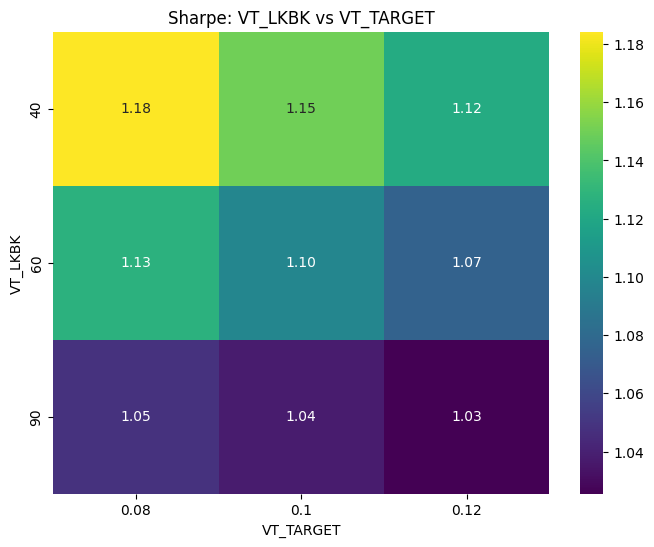

In [25]:

heatmap(df, x="VT_TARGET", y="VT_LKBK", metric="Sharpe")


In [13]:
def plot_sensitivity(df, param, metric="Sharpe"):
    g = df.groupby(param)[metric].mean()
    plt.figure(figsize=(7, 4))
    plt.plot(g.index, g.values, marker="o")
    plt.title(f"{metric} vs {param}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()



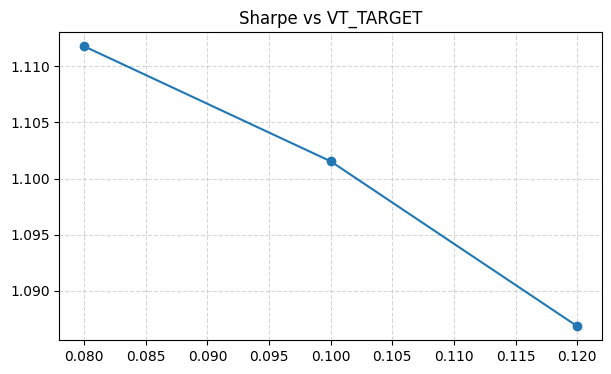

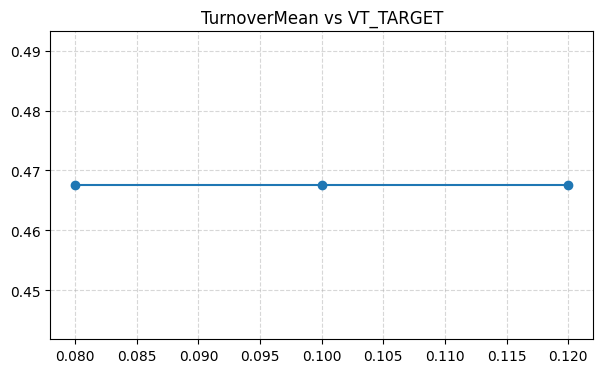

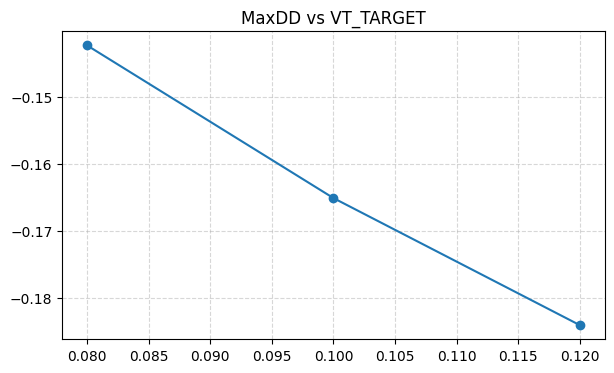

In [23]:

plot_sensitivity(df, "VT_TARGET", "Sharpe")
plot_sensitivity(df, "VT_TARGET", "TurnoverMean")
plot_sensitivity(df, "VT_TARGET", "MaxDD")


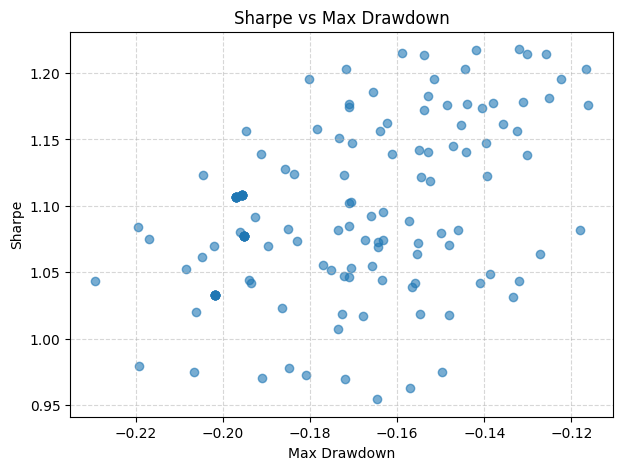

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(df["MaxDD"], df["Sharpe"], alpha=0.6)
plt.xlabel("Max Drawdown")
plt.ylabel("Sharpe")
plt.title("Sharpe vs Max Drawdown")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [22]:
BASE = dict( EMA_ALPHA=0.30,  VT_LKBK=60, GROSS_CAP=1.25 )

def one_at_a_time(px, rets, rbd, static_cfg, base_params, param, values):
    rows = []
    for v in values:
        p = dict(base_params)
        p[param] = v
        ret, W = run_strategy_params(px=px, rets=rets, rbd=rbd, **static_cfg, **p)
        stats = evaluate_run(ret, W)
        rows.append({param: v, **stats})
    return pd.DataFrame(rows).sort_values("Sharpe", ascending=False)

sens_ema = one_at_a_time(px, rets_gs, rbd_gs, static_cfg, BASE, "VT_TARGET", [None, 0.08, 0.10, 0.12])
print(sens_ema.round(3))


   VT_TARGET   CAGR  Sharpe    Vol  Sortino  MaxDD  TurnoverMean  \
1       0.08  0.107   1.311  0.080    1.569 -0.140         0.357   
2       0.10  0.120   1.261  0.093    1.481 -0.164         0.357   
3       0.12  0.127   1.222  0.103    1.405 -0.186         0.357   
0        NaN  0.122   1.206  0.099    1.382 -0.196         0.357   

   TurnoverMedian  TurnoverP90  TotalReturn  
1           0.239         0.51        2.787  
2           0.239         0.51        3.400  
3           0.239         0.51        3.814  
0           0.239         0.51        3.504  
